# MNIST coarse/local MST grid

Compare hierarchical IMSTE on a stratified sample of 8,000 MNIST images. The top row shows exact embeddings for 2, 3, 4, and 8 MST iterations; the rows below show the configured coarse/local grid.

In [7]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import sys
from pathlib import Path
from IPython.display import display

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'mst_embedding').is_dir()),
    None,
)
if repo_root is not None:
    for path in (repo_root, repo_root / 'notebooks'):
        if str(path) not in sys.path:
            sys.path.insert(0, str(path))

from hierarchical_quality_utils import run_mnist_parameter_grid

# MNIST sample and reference graph.
N_INSTANCES = 8_000
DATA_SEED = 42
MODEL_SEED = 42
N_MSTS = 8
EXACT_MST_VALUES = (2, 3, 4, 8)
N_EPOCHS = 600
N_CLUSTERS = 100

# Rows are N_COARSE_MSTS; columns are N_LOCAL_MSTS.
N_COARSE_MSTS_VALUES = (2, 3, 4, 8)
N_LOCAL_MSTS_VALUES = (2, 3, 4, 8)
N_JOBS = -1
MINKOWSKI_P = 2.0

parameter_grid, exact_reference, embeddings, digit_labels, exact_embeddings = run_mnist_parameter_grid(
    coarse_mst_values=N_COARSE_MSTS_VALUES,
    local_mst_values=N_LOCAL_MSTS_VALUES,
    max_samples=N_INSTANCES,
    data_seed=DATA_SEED,
    model_seed=MODEL_SEED,
    n_msts=N_MSTS,
    exact_mst_values=EXACT_MST_VALUES,
    n_epochs=N_EPOCHS,
    n_clusters=N_CLUSTERS,
    n_jobs=N_JOBS,
    minkowski_p=MINKOWSKI_P,
)

display(exact_reference)
display(parameter_grid)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Fixed MNIST grid data: 8,000 samples × 784 features; coarse values=(2, 3, 4, 8); local values=(2, 3, 4, 8)


{'unique_edges': 63992,
 'trustworthiness': 0.907670068570355,
 '5NN_accuracy': 0.8625,
 'graph_construction_seconds': 10.709809792024316,
 'embedding_optimization_seconds': 15.184068124974146,
 'fit_time_seconds': 25.899780916020973,
 'wall_time_seconds': 25.899804041022435}

,n_coarse_msts,n_local_msts,effective_coarse_msts,unique_edges,exact_edge_precision,exact_edge_recall,trustworthiness,5NN_accuracy,delta_trustworthiness,delta_5NN_accuracy,delta_fit_time_seconds,graph_construction_seconds,embedding_optimization_seconds,fit_time_seconds,wall_time_seconds
0,2,2,2,20441,0.946236,0.302257,0.878733,0.760625,-0.028937,-0.101875,-21.089194,0.411279,4.397546,4.810587,4.810610
1,2,3,2,31254,0.907436,0.443196,0.911486,0.798625,0.003816,-0.063875,-18.164882,0.438847,7.294324,7.734899,7.734925
2,2,4,2,42426,0.860769,0.570681,0.916062,0.805375,0.008392,-0.057125,-12.934704,0.525058,12.434439,12.965077,12.965125
3,2,8,2,89794,0.603648,0.847043,0.918573,0.797125,0.010903,-0.065375,0.391773,0.836815,25.442863,26.291554,26.291614
4,3,2,3,21722,0.940107,0.319118,0.868499,0.736875,-0.039171,-0.125625,-19.393939,0.578177,5.923314,6.505841,6.505904
5,3,3,3,33344,0.898482,0.468168,0.890575,0.783750,-0.017095,-0.078750,-16.002765,0.602959,9.289890,9.897016,9.897050
6,3,4,3,45483,0.848251,0.602903,0.894739,0.772250,-0.012931,-0.090250,-13.519350,0.682393,11.693984,12.380431,12.380466
7,3,8,3,98120,0.581258,0.891252,0.910895,0.801750,0.003225,-0.060750,0.566460,0.916170,25.542708,26.466241,26.466275
8,4,2,4,22664,0.932889,0.330401,0.868563,0.756875,-0.039108,-0.105625,-19.231520,0.628800,6.036821,6.668261,6.668297
9,4,3,4,34927,0.888825,0.485123,0.888993,0.772000,-0.018677,-0.090500,-16.225317,0.725286,8.947286,9.674464,9.674486


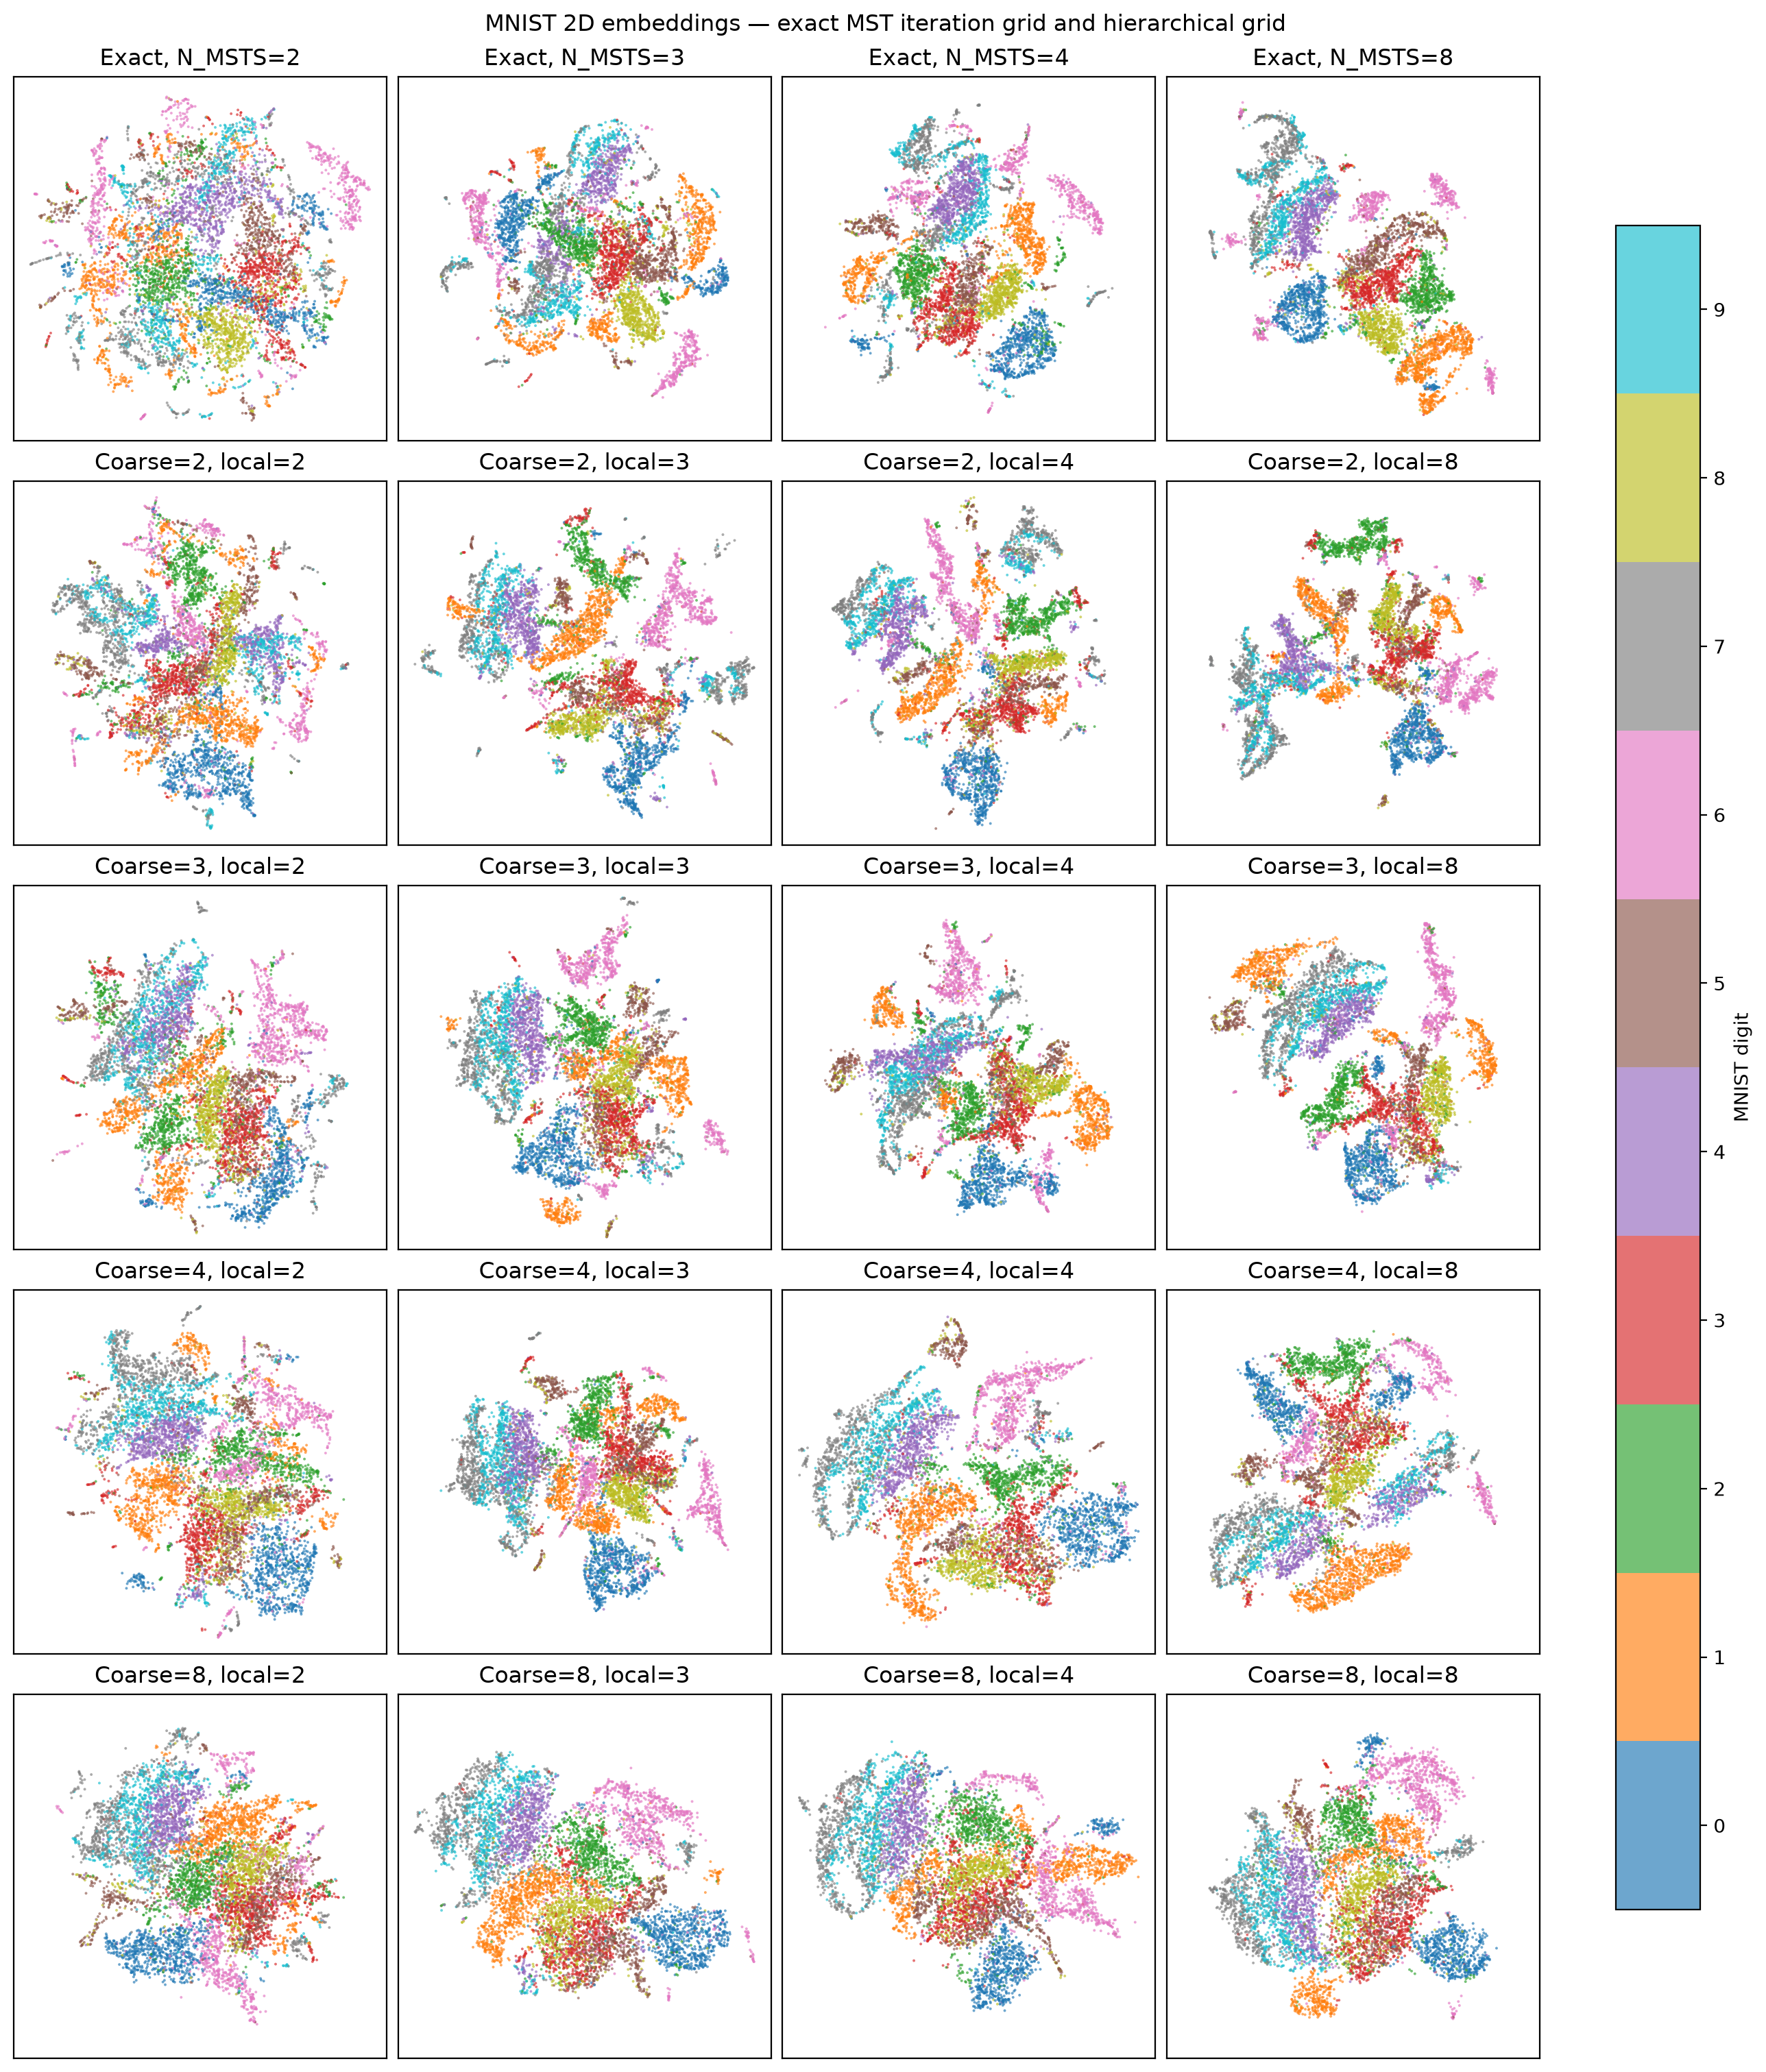

In [8]:
from hierarchical_quality_utils import plot_mnist_embedding_grid

grid_figure = plot_mnist_embedding_grid(
    embeddings,
    digit_labels,
    exact_embeddings,
    coarse_mst_values=N_COARSE_MSTS_VALUES,
    local_mst_values=N_LOCAL_MSTS_VALUES,
)
grid_figure
